In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import spacy
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import TextVectorization
from collections import Counter
import numpy as np

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.callbacks import TensorBoard

In [5]:
df = pd.read_csv("../../asset/sentiment140_cleaned.csv")

In [6]:
df

,target,text,text_clean,text_nlp
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww thats a bummer you shoulda got david carr...,awww bummer shoulda get david carr day
1,0,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...,upset not update facebook texte cry result sch...
2,0,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...,dive time ball manage save rest bound
3,0,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire,body feel itchy like fire
4,0,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i her...,behave mad not
...,...,...,...,...
1587843,1,Just woke up. Having no school is the best fee...,just woke up having no school is the best feel...,wake have school good feeling
1587844,1,TheWDB.com - Very cool to hear old Walt interv...,thewdbcom very cool to hear old walt interviews,thewdbcom cool hear old walt interview
1587845,1,Are you ready for your MoJo Makeover? Ask me f...,are you ready for your mojo makeover ask me fo...,ready mojo makeover ask detail
1587846,1,Happy 38th Birthday to my boo of alll time!!! ...,happy th birthday to my boo of alll time tupac...,happy th birthday boo alll time tupac amaru sh...


In [8]:
df = df.dropna(subset=["text_clean"]).reset_index(drop=True)

X = df["text_clean"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"Train : {len(X_train):,} | Test : {len(X_test):,}")

Train : 1,270,277 | Test : 317,570


In [10]:
VOCAB_SIZE=15000
MAX_LEN=40
BATCH_SIZE=200_000

counter = Counter()
for i in range(0, len(X_train), BATCH_SIZE):
    batch = X_train[i : i + BATCH_SIZE]
    for text in batch:
        counter.update(text.split())
    print(f"Batch {i // BATCH_SIZE + 1} compté")

vocab = ['', '[UNK]'] + [word for word, _ in counter.most_common(VOCAB_SIZE - 2)]

vectorizer = TextVectorization(max_tokens=VOCAB_SIZE, output_sequence_length=MAX_LEN)
vectorizer.set_vocabulary(vocab)
print("Terminé !")

Batch 1 compté
Batch 2 compté
Batch 3 compté
Batch 4 compté
Batch 5 compté
Batch 6 compté
Batch 7 compté
Terminé !


E0000 00:00:1776515980.152154   27616 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [11]:
def vectorize_in_batches(data, vectorizer, batch_size):
    results = []
    total = len(data)
    
    for i in range(0, total, batch_size):
        batch = data[i : i + batch_size]
        vectorized = vectorizer(batch)
        results.append(vectorized.numpy())
        print(f"Batch {i // batch_size + 1}/{-(-total // batch_size)} traité — {min(i + batch_size, total):,} / {total:,}")
    
    return np.concatenate(results, axis=0)

X_train_vec = vectorize_in_batches(X_train, vectorizer, BATCH_SIZE)
X_test_vec  = vectorize_in_batches(X_test,  vectorizer, BATCH_SIZE)

print(f"X_train_vec shape : {X_train_vec.shape}")
print(f"X_test_vec shape  : {X_test_vec.shape}")

W0000 00:00:1776515980.359776   27616 cpu_allocator_impl.cc:82] Allocation of 29737392 exceeds 10% of free system memory.
W0000 00:00:1776515980.471330   27616 cpu_allocator_impl.cc:82] Allocation of 64000000 exceeds 10% of free system memory.
W0000 00:00:1776515980.656993   27616 cpu_allocator_impl.cc:82] Allocation of 29621928 exceeds 10% of free system memory.


Batch 1/7 traité — 200,000 / 1,270,277


W0000 00:00:1776515980.734074   27616 cpu_allocator_impl.cc:82] Allocation of 64000000 exceeds 10% of free system memory.
W0000 00:00:1776515980.917434   27616 cpu_allocator_impl.cc:82] Allocation of 29638200 exceeds 10% of free system memory.


Batch 2/7 traité — 400,000 / 1,270,277
Batch 3/7 traité — 600,000 / 1,270,277
Batch 4/7 traité — 800,000 / 1,270,277
Batch 5/7 traité — 1,000,000 / 1,270,277
Batch 6/7 traité — 1,200,000 / 1,270,277
Batch 7/7 traité — 1,270,277 / 1,270,277
Batch 1/2 traité — 200,000 / 317,570
Batch 2/2 traité — 317,570 / 317,570
X_train_vec shape : (1270277, 40)
X_test_vec shape  : (317570, 40)


In [12]:
EMBEDDING_DIM = 64   # dimension des vecteurs d'embedding

model = Sequential([
    # Couche Embedding : transforme chaque token (entier) en vecteur dense
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),

    # LTSM Bidirectionnel : lit la séquence dans les deux sens
    Bidirectional(LSTM(64, return_sequences=False)),

    # Dropout : désactive aléatoirement 40% des neurones → évite l'overfitting
    Dropout(0.4),

    # Couche Dense intérmediaire
    Dense(32, activation='relu'),

    Dropout(0.2),
    
    # Couche de sortie : 1 neurone, sigmoid → probabilité entre 0 et 1
    Dense(1, activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # classification binaire
    metrics=['accuracy']
)
model.build(input_shape=(None, MAX_LEN))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 40, 64)         │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,030,209 (3.93 MB)

 Trainable params: 1,030,209 (3.93 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

tb = TensorBoard(log_dir='./logs', histogram_freq=1)

model.fit(
    X_train_vec, y_train,
    shuffle=True,
    epochs=30,
    validation_split=0.1,
    batch_size=512,
    callbacks=[early_stop, tb],
    verbose=1
)

Epoch 1/30
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 181s 80ms/step - accuracy: 0.7674 - loss: 0.4851 - val_accuracy: 0.7795 - val_loss: 0.4621
Epoch 2/30
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 173s 78ms/step - accuracy: 0.7847 - loss: 0.4572 - val_accuracy: 0.7832 - val_loss: 0.4575
Epoch 3/30
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 160s 71ms/step - accuracy: 0.7907 - loss: 0.4461 - val_accuracy: 0.7840 - val_loss: 0.4568
Epoch 4/30
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 171s 76ms/step - accuracy: 0.7963 - loss: 0.4362 - val_accuracy: 0.7833 - val_loss: 0.4618
Epoch 5/30
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 167s 75ms/step - accuracy: 0.8013 - loss: 0.4262 - val_accuracy: 0.7833 - val_loss: 0.4674
Epoch 6/30
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 157s 70ms/step - accuracy: 0.8062 - loss: 0.4164 - val_accuracy: 0.7818 - val_loss: 0.4724
Epoch 7/30
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 157s 70ms/step - accuracy: 0.8111 - loss: 0.4063 - val_accuracy: 0.7810 - val_loss: 0.4872


## Evalusation du model 

In [15]:
loss, accuracy = model.evaluate(X_test_vec, y_test, verbose=1)
print(f"Loss     : {loss:.4f}")
print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")

9925/9925 ━━━━━━━━━━━━━━━━━━━━ 69s 7ms/step - accuracy: 0.7832 - loss: 0.4577
Loss     : 0.4577
Accuracy : 0.7832 (78.32%)


In [17]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (model.predict(X_test_vec) > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Négatif', 'Positif']))

9925/9925 ━━━━━━━━━━━━━━━━━━━━ 64s 6ms/step
              precision    recall  f1-score   support

     Négatif       0.79      0.77      0.78    158880
     Positif       0.77      0.80      0.79    158690

    accuracy                           0.78    317570
   macro avg       0.78      0.78      0.78    317570
weighted avg       0.78      0.78      0.78    317570



In [18]:
model.save('sentiment_visu.keras')
print("Model save !")

Model save !


In [9]:
# ===== PARAMÈTRES =====
VOCAB_SIZE = 20000
MAX_LEN    = 60
BATCH_SIZE = 200_000

counter = Counter()
for i in range(0, len(X_train), BATCH_SIZE):
    batch = X_train[i : i + BATCH_SIZE]
    for text in batch:
        counter.update(text.split())
    print(f"Batch {i // BATCH_SIZE + 1} compté")

vocab = ['', '[UNK]'] + [word for word, _ in counter.most_common(VOCAB_SIZE - 2)]

vectorizer = TextVectorization(max_tokens=VOCAB_SIZE, output_sequence_length=MAX_LEN)
vectorizer.set_vocabulary(vocab)
print("Terminé !")

Batch 1 compté
Batch 2 compté
Batch 3 compté
Batch 4 compté
Batch 5 compté
Batch 6 compté
Batch 7 compté
Terminé !


In [10]:
def vectorize_in_batches(data, vectorizer, batch_size):
    results = []
    total = len(data)
    
    for i in range(0, total, batch_size):
        batch = data[i : i + batch_size]
        vectorized = vectorizer(batch)
        results.append(vectorized.numpy())
        print(f"Batch {i // batch_size + 1}/{-(-total // batch_size)} traité — {min(i + batch_size, total):,} / {total:,}")
    
    return np.concatenate(results, axis=0)

X_train_vec = vectorize_in_batches(X_train, vectorizer, BATCH_SIZE)
X_test_vec  = vectorize_in_batches(X_test,  vectorizer, BATCH_SIZE)

print(f"X_train_vec shape : {X_train_vec.shape}")
print(f"X_test_vec shape  : {X_test_vec.shape}")

Batch 1/7 traité — 200,000 / 1,270,277
Batch 2/7 traité — 400,000 / 1,270,277
Batch 3/7 traité — 600,000 / 1,270,277
Batch 4/7 traité — 800,000 / 1,270,277
Batch 5/7 traité — 1,000,000 / 1,270,277
Batch 6/7 traité — 1,200,000 / 1,270,277
Batch 7/7 traité — 1,270,277 / 1,270,277
Batch 1/2 traité — 200,000 / 317,570
Batch 2/2 traité — 317,570 / 317,570
X_train_vec shape : (1270277, 60)
X_test_vec shape  : (317570, 60)


In [12]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# ===== MODÈLE =====
model = Sequential([
    Embedding(VOCAB_SIZE, 128, mask_zero=True),
    Bidirectional(LSTM(128, return_sequences=True)),
    Bidirectional(LSTM(64)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ===== CALLBACKS =====
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

history = model.fit(
    X_train_vec, y_train,
    epochs=10,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10


W0000 00:00:1776520557.094758   36737 cpu_allocator_impl.cc:82] Allocation of 548759520 exceeds 10% of free system memory.


2233/2233 ━━━━━━━━━━━━━━━━━━━━ 1346s 601ms/step - accuracy: 0.7943 - loss: 0.4436 - val_accuracy: 0.8104 - val_loss: 0.4127 - learning_rate: 3.0000e-04
Epoch 2/10
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 1275s 571ms/step - accuracy: 0.8193 - loss: 0.3982 - val_accuracy: 0.8199 - val_loss: 0.3978 - learning_rate: 3.0000e-04
Epoch 3/10
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 1299s 582ms/step - accuracy: 0.8300 - loss: 0.3785 - val_accuracy: 0.8220 - val_loss: 0.3943 - learning_rate: 3.0000e-04
Epoch 4/10
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 1297s 581ms/step - accuracy: 0.8378 - loss: 0.3635 - val_accuracy: 0.8219 - val_loss: 0.3964 - learning_rate: 3.0000e-04
Epoch 5/10
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.8475 - loss: 0.3444
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 1286s 576ms/step - accuracy: 0.8449 - loss: 0.3490 - val_accuracy: 0.8216 - val_loss: 0.4019 - learning_rate: 3.0000e-04
Epoch 6/10
2233/2233 ━━━━━━━━━━━━━━━━━━━━

In [14]:
loss, accuracy = model.evaluate(X_test_vec, y_test, verbose=1)

9925/9925 ━━━━━━━━━━━━━━━━━━━━ 310s 31ms/step - accuracy: 0.8211 - loss: 0.3947


In [15]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (model.predict(X_test_vec) > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Négatif', 'Positif']))

9925/9925 ━━━━━━━━━━━━━━━━━━━━ 356s 36ms/step
              precision    recall  f1-score   support

     Négatif       0.81      0.84      0.82    158880
     Positif       0.83      0.80      0.82    158690

    accuracy                           0.82    317570
   macro avg       0.82      0.82      0.82    317570
weighted avg       0.82      0.82      0.82    317570



In [16]:
model.save('Final.keras')
print("Model save") 

Model save


In [17]:
cm = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :")
print(cm)

Matrice de confusion :
[[133319  25561]
 [ 31264 127426]]


In [19]:
import subprocess
subprocess.run(["pip", "install", "plotly"], check=True)

CompletedProcess(args=['pip', 'install', 'plotly'], returncode=0)

In [20]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

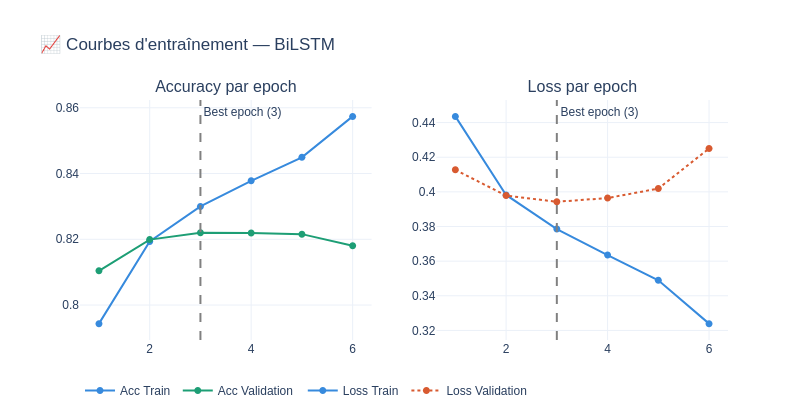

In [21]:
# ── Accuracy & Loss ──────────────────────────────────────────────
hist = history.history
epochs = list(range(1, len(hist['accuracy']) + 1))

df_acc = pd.DataFrame({
    'Epoch'     : epochs * 2,
    'Accuracy'  : hist['accuracy'] + hist['val_accuracy'],
    'Jeu'       : ['Train'] * len(epochs) + ['Validation'] * len(epochs)
})

df_loss = pd.DataFrame({
    'Epoch' : epochs * 2,
    'Loss'  : hist['loss'] + hist['val_loss'],
    'Jeu'   : ['Train'] * len(epochs) + ['Validation'] * len(epochs)
})

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("Accuracy par epoch", "Loss par epoch"))

for jeu, color in [('Train', '#378ADD'), ('Validation', '#1D9E75')]:
    d = df_acc[df_acc['Jeu'] == jeu]
    fig.add_trace(go.Scatter(x=d['Epoch'], y=d['Accuracy'],
                             mode='lines+markers', name=f'Acc {jeu}',
                             line=dict(color=color, width=2),
                             marker=dict(size=7)), row=1, col=1)

for jeu, color in [('Train', '#378ADD'), ('Validation', '#D85A30')]:
    d = df_loss[df_loss['Jeu'] == jeu]
    fig.add_trace(go.Scatter(x=d['Epoch'], y=d['Loss'],
                             mode='lines+markers', name=f'Loss {jeu}',
                             line=dict(color=color, width=2, dash='dot' if jeu=='Validation' else 'solid'),
                             marker=dict(size=7)), row=1, col=2)

# Ligne verticale sur la meilleure epoch (val_loss min)
best_epoch = int(np.argmin(hist['val_loss'])) + 1
for col in [1, 2]:
    fig.add_vline(x=best_epoch, line_dash='dash', line_color='gray',
                  annotation_text=f'Best epoch ({best_epoch})',
                  annotation_position='top right', row=1, col=col)

fig.update_layout(title='📈 Courbes d\'entraînement — BiLSTM',
                  template='plotly_white', height=420,
                  legend=dict(orientation='h', y=-0.15))
fig.show()

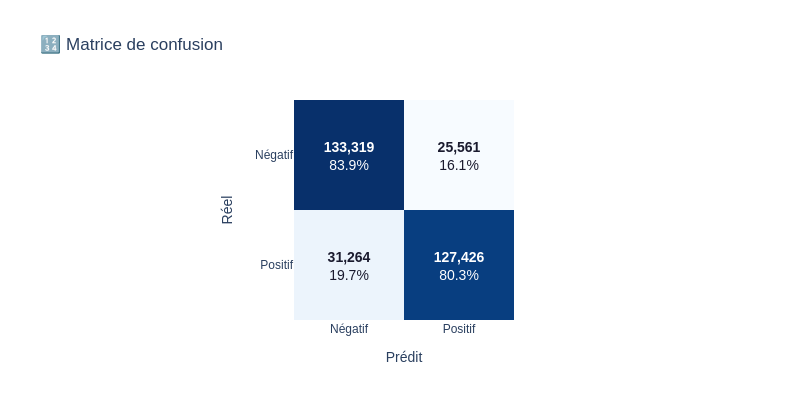

In [22]:
# ── Matrice de confusion ─────────────────────────────────────────
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
labels = ['Négatif', 'Positif']

# Annotations : valeur + pourcentage ligne
annots = []
for i in range(2):
    row = []
    for j in range(2):
        pct = cm[i, j] / cm[i].sum() * 100
        row.append(f"<b>{cm[i,j]:,}</b><br>{pct:.1f}%")
    annots.append(row)

fig_cm = px.imshow(
    cm,
    labels=dict(x='Prédit', y='Réel', color='Count'),
    x=labels, y=labels,
    color_continuous_scale='Blues',
    title='🔢 Matrice de confusion',
    text_auto=False
)

# Surcharge des annotations custom
for i in range(2):
    for j in range(2):
        fig_cm.add_annotation(
            x=j, y=i,
            text=annots[i][j],
            showarrow=False,
            font=dict(color='white' if cm[i,j] > cm.max()*0.5 else '#1a1a2e', size=14)
        )

fig_cm.update_layout(template='plotly_white', height=400,
                     coloraxis_showscale=False)
fig_cm.show()

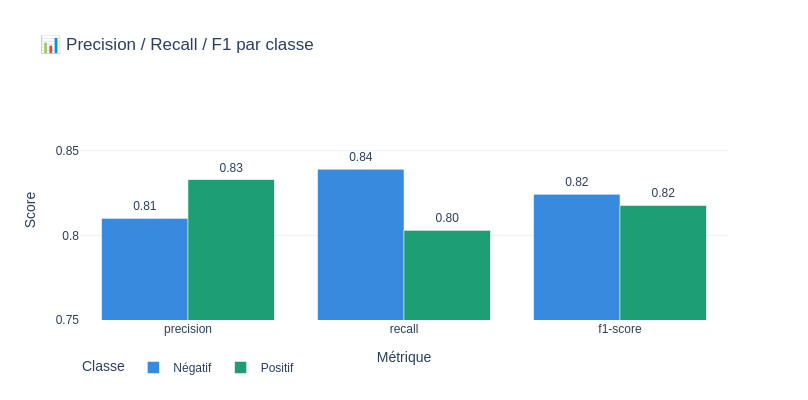

In [23]:
# ── Métriques par classe ─────────────────────────────────────────
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred,
                                target_names=['Négatif', 'Positif'],
                                output_dict=True)

df_metrics = pd.DataFrame([
    {'Classe': cls, 'Métrique': met, 'Score': report[cls][met]}
    for cls in ['Négatif', 'Positif']
    for met in ['precision', 'recall', 'f1-score']
])

fig_bar = px.bar(
    df_metrics,
    x='Métrique', y='Score', color='Classe',
    barmode='group',
    color_discrete_map={'Négatif': '#378ADD', 'Positif': '#1D9E75'},
    title='📊 Precision / Recall / F1 par classe',
    text=df_metrics['Score'].apply(lambda x: f'{x:.2f}'),
    range_y=[0.75, 0.88]
)

fig_bar.update_traces(textposition='outside')
fig_bar.update_layout(template='plotly_white', height=400,
                      legend=dict(orientation='h', y=-0.15))
fig_bar.show()

In [24]:
import pickle
with open('vectorizer_final.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
print("Vectorizer sauvegardé !")

Vectorizer sauvegardé !
